<a href="https://colab.research.google.com/github/juliosdutra/modelagem-processos-dados/blob/main/notebooks/Exemplo_energy_efficiency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔹 Exemplo em Python

👉 Esse notebook apresenta:
* Leitura dos dados,
* Exploração inicial (estatística + correlação),
* Um mini modelo de regressão linear para prever a carga de aquecimento.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# URL do dataset no GitHub
url = "https://raw.githubusercontent.com/juliosdutra/modelagem-processos-dados/refs/heads/main/dados/energy_efficiency.csv"

# Carregar dados
df = pd.read_csv(url)

# Ver as primeiras linhas
print("Formato do dataset:", df.shape)
df.head()



Formato do dataset: (768, 10)


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


# 🔹 Estatísticas e informações

In [3]:
# Informações gerais
df.info()

# Estatísticas descritivas
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


# 🔹 Relação entre variáveis e cargas térmicas

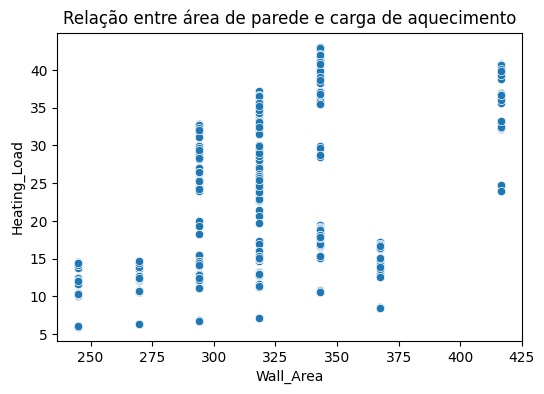

In [4]:
# Scatterplot entre Área da Parede (Wall_Area) e Carga de Aquecimento (Heating_Load)
plt.figure(figsize=(6,4))
sns.scatterplot(x="Wall_Area", y="Heating_Load", data=df)
plt.title("Relação entre área de parede e carga de aquecimento")
plt.show()

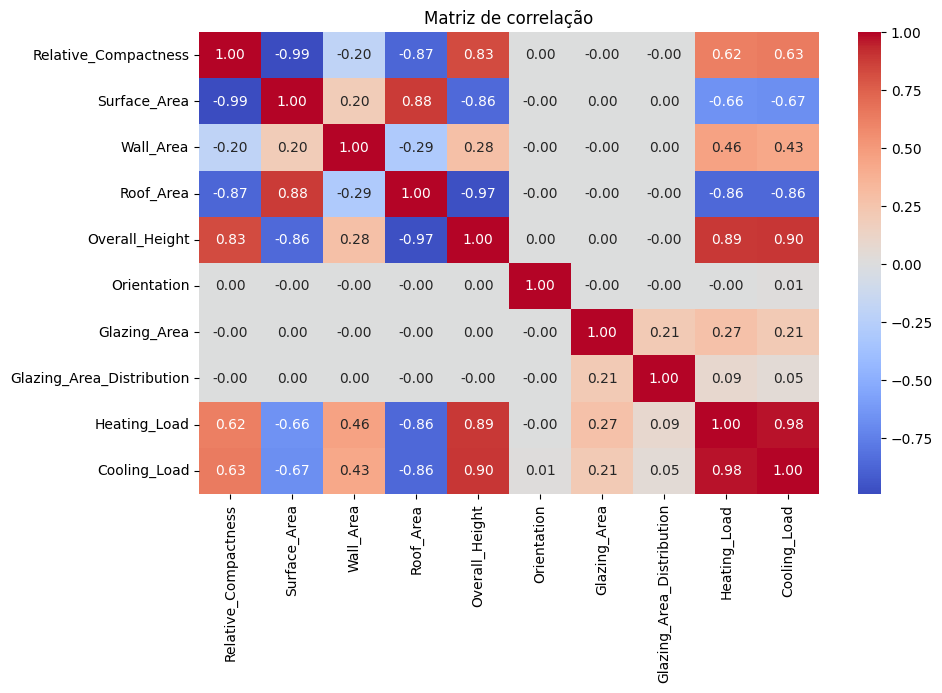

In [5]:
# Correlação entre todas as variáveis
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Matriz de correlação")
plt.show()

# 🔹 Pequeno modelo de regressão

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Variáveis explicativas (8 primeiras colunas) e target (Heating_Load)
X = df.drop(columns=["Heating_Load", "Cooling_Load"])
y = df["Heating_Load"]

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Prever e avaliar
y_pred = model.predict(X_test)
print("R² no conjunto de teste:", r2_score(y_test, y_pred))


R² no conjunto de teste: 0.9121846294352439
